# Imports

In [279]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import pydicom
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [280]:
#seed used for random
seed = 42
torch.manual_seed(seed)

# Loading measurement data

In [281]:
#read csv
df = pd.read_csv("../data/measurements.csv")

print(df.columns)

#drop unnecessary columns
df.drop(columns = ["Student Name", "Notes", "Unnamed: 23", "Unnamed: 24", "Unnamed: 25", "Unnamed: 26"], inplace = True)

print(df.columns)

print(len(df.columns.values))

Index(['Student Name', 'ID', 'L Medial Cortical Thickness',
       'L Lateral Cortical Thickness ', 'L Shaft Width',
       'L Femoral Head Diameter', 'L Horizontal Offset', 'L Vertical Offset',
       'L Femoral Neck Width', 'L Hip Axis Length',
       'L Femoral Neck Axis Length', 'L Femoral Neck-Shaft  Angle',
       'R Medial Cortical Thickness', 'R Lateral Cortical Thickness ',
       'R Shaft Width', 'R Femoral Head Diameter', 'R Horizontal Offset',
       'R Vertical Offset', 'R Femoral Neck Width', 'R Hip Axis Length',
       'R Femoral Neck Axis Length', 'R Femoral Neck-Shaft  Angle', 'Notes',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26'],
      dtype='object')
Index(['ID', 'L Medial Cortical Thickness', 'L Lateral Cortical Thickness ',
       'L Shaft Width', 'L Femoral Head Diameter', 'L Horizontal Offset',
       'L Vertical Offset', 'L Femoral Neck Width', 'L Hip Axis Length',
       'L Femoral Neck Axis Length', 'L Femoral Neck-Shaft  Angle',
       '

In [282]:
#get rid of images with na (only temporary for convenience)
df = df.dropna()

# Load image data (datasets and dataloaders)

In [283]:
#image directory
img_dir = "../data/box_images"

#train test split
train_test_split = 0.8

#batch size
batch_size = 8

#pixels to mm conversion (known)
pix_to_mm = 408 / 2400

#image size (pix)
img_width = 2400
img_height = 1920

#training scale factor
scale_factor = 0.1

In [284]:
img_width = int(img_width * scale_factor)
img_height = int(img_height * scale_factor)

In [285]:
class ImageDataset(Dataset):
    def __init__(self, img_dir, img_files, img_transform = None):
        self.img_dir = img_dir
        self.img_files = img_files
        self.img_transform = img_transform

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_dir + '/' + self.img_files[idx]
        ds = pydicom.dcmread(img_path)
        img = ds.pixel_array

        img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
        img = img.astype(np.uint8)

        img = Image.fromarray(img)

        if self.img_transform:
            img = self.img_transform(img)
        
        return img, self.img_files[idx]
        

In [286]:
#all images in directory
all_img_in_dir = [i for i in os.listdir(img_dir) if i.lower().endswith("dcm")]

#check all images in df are loaded (else throw error)
for i in df['ID'].values:
    if i not in all_img_in_dir:
        raise SystemError(f'Directory is missing images: {i}')
    
#load only images in the df
all_img = [i for i in all_img_in_dir if i in df['ID'].values]
print(f'Images in use: {len(all_img)}/{len(all_img_in_dir)}')

#split train and test sets
all_idx = torch.randperm(len(all_img))
train_img = [all_img[i] for i in all_idx[:int(train_test_split * len(all_img))]]
test_img = [all_img[i] for i in all_idx[int(train_test_split * len(all_img)):]]

Images in use: 102/3094


In [287]:
#transform used for training
train_transform = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    # transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

#transform used for testing
test_transform = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [288]:
#training dataset and data loader
train_set = ImageDataset(img_dir, train_img, train_transform)
train_loader = DataLoader(train_set, batch_size = batch_size, shuffle = True)

#testing dataset and data loader
test_set = ImageDataset(img_dir, test_img, test_transform)
test_loader = DataLoader(test_set, batch_size = batch_size, shuffle = False)

('9020999_20040803.dcm', '9037823_20040916.dcm', '9995913_20041215.dcm', '9995277_20040910.dcm', '9013161_20060524.dcm', '9012435_20050128.dcm', '9021195_20050525.dcm', '9005321_20040908.dcm')
torch.Size([1, 192, 240])


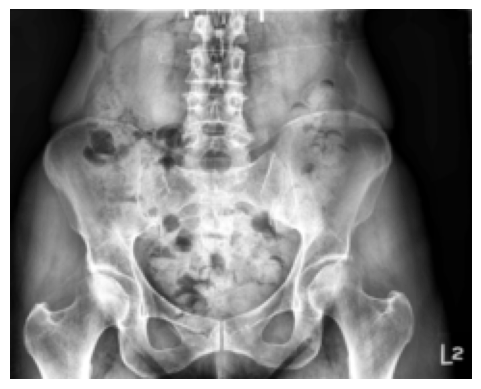

('9022703_20050617.dcm', '9036316_20041027.dcm', '9021791_20040922.dcm', '9018389_20050113.dcm', '9028904_20050621.dcm', '9030418_20050718.dcm', '9013798_20040920.dcm', '9017909_20050729.dcm')
torch.Size([1, 192, 240])


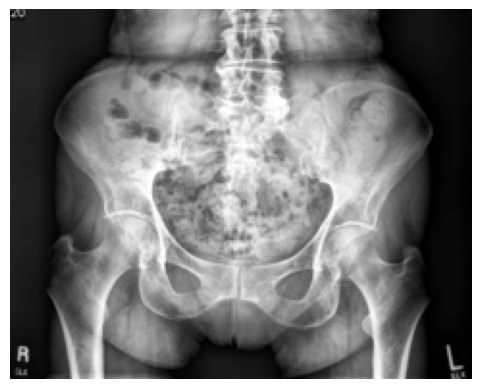

('9031141_20040909.dcm', '9019907_20050706.dcm', '9010060_20041027.dcm', '9994363_20041229.dcm', '9038683_20041012.dcm', '9011918_20050614.dcm', '9027189_20050607.dcm', '9010952_20050105.dcm')
torch.Size([1, 192, 240])


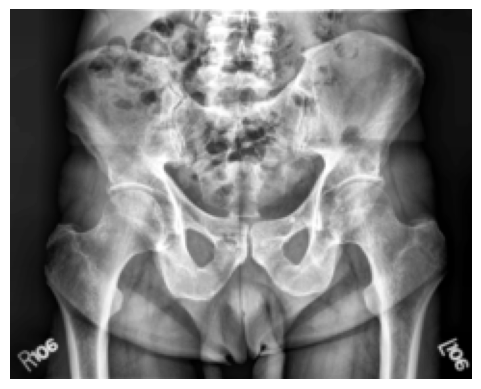

('9014797_20041007.dcm', '9026695_20050624.dcm', '9997869_20050103.dcm', '9005413_20041202.dcm', '9007827_20041006.dcm', '9003175_20050616.dcm', '9034223_20050701.dcm', '9004669_20050714.dcm')
torch.Size([1, 192, 240])


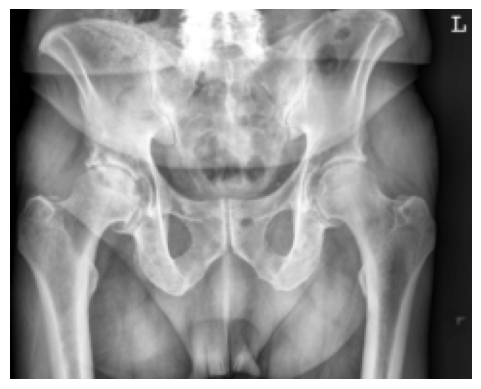

('9998384_20041230.dcm', '9003430_20050613.dcm', '9998352_20050622.dcm', '9018291_20040917.dcm', '9029791_20040916.dcm', '9016886_20050112.dcm', '9036770_20041115.dcm', '9025257_20041216.dcm')
torch.Size([1, 192, 240])


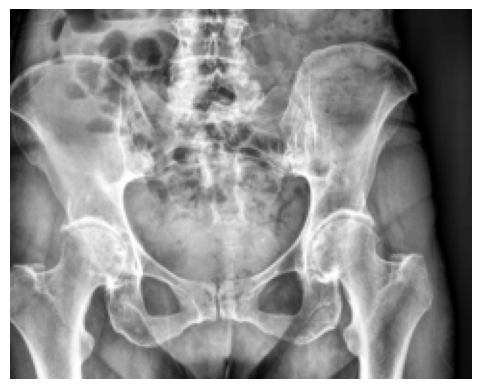

('9996284_20040927.dcm', '9000296_20040909.dcm', '9996865_20050111.dcm', '9008820_20040930.dcm', '9994408_20040818.dcm', '9016918_20050623.dcm', '9020404_20050706.dcm', '9013941_20050114.dcm')
torch.Size([1, 192, 240])


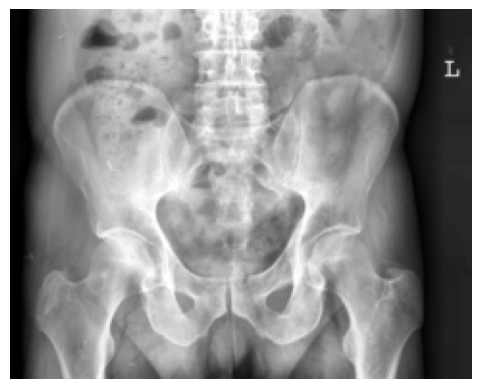

('9004175_20050523.dcm', '9011420_20050627.dcm', '9027281_20041118.dcm', '9023193_20050617.dcm', '9024900_20050822.dcm', '9036948_20050202.dcm', '9028786_20040922.dcm', '9002817_20050330.dcm')
torch.Size([1, 192, 240])


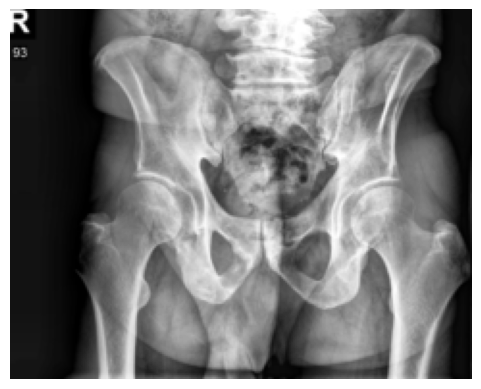

('9023784_20040909.dcm', '9006407_20050107.dcm', '9018489_20040819.dcm', '9037494_20050725.dcm', '9008561_20041028.dcm', '9019406_20050617.dcm', '9002316_20040831.dcm', '9016403_20050121.dcm')
torch.Size([1, 192, 240])


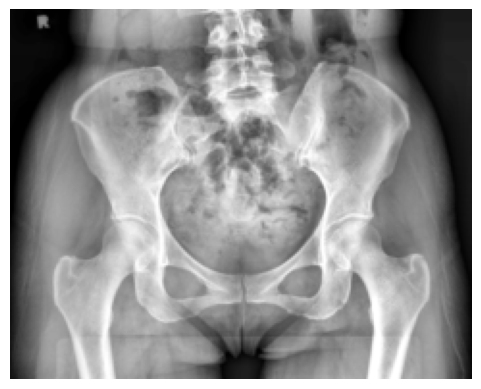

('9036287_20060124.dcm', '9035449_20050121.dcm', '9031426_20050623.dcm', '9022408_20050620.dcm', '9024409_20050712.dcm', '9029415_20050713.dcm', '9009927_20050711.dcm', '9034963_20050125.dcm')
torch.Size([1, 192, 240])


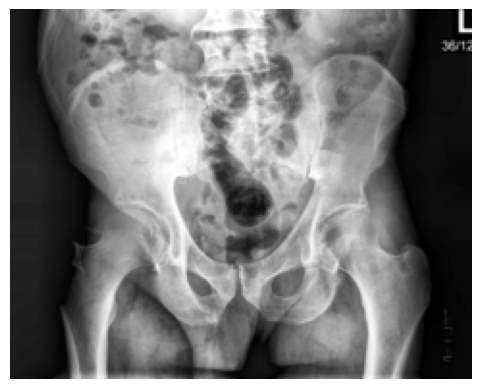

('9033275_20060201.dcm', '9005942_20050624.dcm', '9035779_20041115.dcm', '9014209_20050606.dcm', '9003658_20050609.dcm', '9010308_20040915.dcm', '9030296_20041008.dcm', '9022902_20050701.dcm')
torch.Size([1, 192, 240])


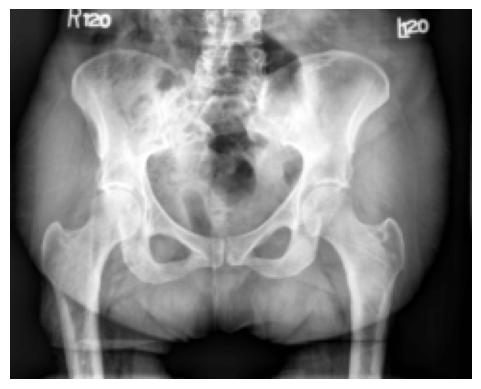

('9003815_20040910.dcm',)
torch.Size([1, 192, 240])


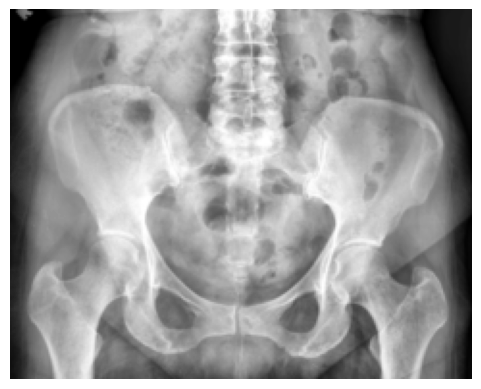

In [289]:
for imgs, files in train_loader:
    print(files)
    print(imgs[0].shape)
    plt.imshow(imgs[0].squeeze(), cmap = 'gray')
    plt.axis('off')
    plt.show()


# Model

In [290]:
#number of epochs
epoch_cnt = 20

#learning rate
learning_rate = 1e-3

In [291]:
#take points from one side (either left or right) and output the requested measurements
def one_side_points_to_measurements(points, pix_to_mm, scale_factor):
    #shape: (batch_size, 14)
    #[A_x, A_y, B_x, B_y, C_x, C_y, D_x, E_x, F_x, G_x, W_x, X_x, Y_x, Z_x]
    #  0    1    2    3    4    5    6    7    8    9   10   11   12   13

    eps = 1e-6
    line1y = lambda x : (points[:, 3] - points[:, 1]) / (points[:, 2] - points[:, 0] + eps) * (x - points[:, 0]) + points[:, 1]
    line2x = lambda y : (points[:, 7] - points[:, 4]) / (line1y(points[:, 7]) - points[:, 5] + eps) * (y - points[:, 5]) + points[:, 4]

    all_x_y = [None for _ in range(12)]
    for i in range(3):
        all_x_y[i] = torch.stack([points[:, 2 * i], points[:, 2 * i + 1]], dim = -1)
    for i in range(3, 7):
        all_x_y[i] = torch.stack([points[:, i + 3], line1y(points[:, i + 3])], dim = -1)
    for i in range(7, 11):
        all_x_y[i] = torch.stack([points[:, i + 3], points[:, 5]], dim = -1)
    all_x_y[11] = torch.stack([line2x(points[:, 1]), points[:, 1]], dim = -1)
    
    all_points = torch.stack(all_x_y, dim = 1)
    #[A, B, C, D, E, F, G, W, X, Y,  Z,  K]
    # 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11

    xdist = lambda ptidx1, ptidx2 : all_points[:, ptidx1, 0] - all_points[:, ptidx2, 0] #signed x distance
    ydist = lambda ptidx1, ptidx2 : all_points[:, ptidx1, 1] - all_points[:, ptidx2, 1] #signed y distance
    dist = lambda ptidx1, ptidx2 : torch.sqrt(xdist(ptidx1, ptidx2) ** 2 + ydist(ptidx1, ptidx2) ** 2) #total distance
    ang = lambda x1, y1, x2, y2 : torch.arccos((x1 * x2 + y1 * y2) / (torch.sqrt(x1 ** 2 + y1 ** 2) * torch.sqrt(x2 ** 2 + y2 ** 2))) * 180 / torch.pi #angle between two vectors

    y = [None for _ in range(10)]
    y[0] = pix_to_mm / scale_factor * dist(7, 8)
    y[1] = pix_to_mm / scale_factor * dist(9, 10)
    y[2] = pix_to_mm / scale_factor * dist(7, 10)
    y[3] = pix_to_mm / scale_factor * 2 * dist(0, 3)
    y[4] = pix_to_mm / scale_factor * dist(0, 11)
    y[5] = pix_to_mm / scale_factor * torch.abs(ydist(0, 2))
    y[6] = pix_to_mm / scale_factor * 2 * torch.sqrt(torch.abs(dist(0, 3) ** 2 - dist(0, 1) ** 2))
    y[7] = pix_to_mm / scale_factor * dist(5, 6)
    y[8] = pix_to_mm / scale_factor * dist(3, 6)
    y[9] = ang(xdist(4, 0), ydist(4, 0), xdist(4, 2), ydist(4, 2))

    return (torch.stack(y, dim = -1), all_points)

In [292]:
#compute left points and then right points
def all_points_to_measurements(points, pix_to_mm, scale_factor):
    #shape: (batch_size, 28)

    l_measurements, l_points = one_side_points_to_measurements(points[:, :14], pix_to_mm, scale_factor)
    r_measurements, r_points = one_side_points_to_measurements(points[:, 14:], pix_to_mm, scale_factor)

    return (torch.cat([l_measurements, r_measurements], dim = 1), torch.cat([l_points, r_points], dim = 1))

In [293]:
#model
class CNNModel(nn.Module):
    def __init__(self, img_width, img_height):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * (img_width // 2 // 2 // 2) * (img_height // 2 // 2 // 2), 128),
            nn.ReLU(),
            nn.Linear(128, 28)
        )

    def forward(self, x):
        x = self.seq(x)
        return x

model = CNNModel(img_width, img_height)

In [294]:
#device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [295]:
#loss function
lossfn = nn.MSELoss()

In [296]:
#optimizer
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [297]:
for epoch in range(epoch_cnt):
    model.to(device)
    model.train()

    total_loss = 0
    
    for images, files in train_loader:
        images = images.to(device)
        
        yvals = []
        for file in files:
            yvals.append(df.loc[df['ID'] == file].drop(columns = 'ID').values.astype(np.float32))
        yvals = torch.from_numpy(np.stack(yvals)).squeeze(1).to(device)

        ypred, ypoints = all_points_to_measurements(model(images), pix_to_mm, scale_factor)

        loss = lossfn(ypred, yvals)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    # if epoch % 10 and epoch != epoch_cnt - 1: #only print every x epochs
    #     continue

    print(f'Epoch: {epoch}\n')
    print(f'Loss (in sample): {total_loss / len(train_set)}')

    total_loss = 0
    total_percent_err = torch.zeros(20).to(device)
    model.eval()
    for images, files in test_loader:
        images = images.to(device)
        
        yvals = []
        for file in files:
            yvals.append(df.loc[df['ID'] == file].drop(columns = 'ID').values.astype(np.float32))
        yvals = torch.from_numpy(np.stack(yvals)).squeeze(1).to(device)

        ypred, ypoints = all_points_to_measurements(model(images), pix_to_mm, scale_factor)

        loss = lossfn(ypred, yvals)
        total_loss += loss.item()

        total_percent_err += torch.sum(torch.abs(yvals - ypred) / yvals, dim = 0)
    
    print(f'Loss (out sample): {total_loss / len(test_set)}\n')
    print(f'Percent error for each measurement (out sample):')
    for i in total_percent_err[:10]:
        print(f'{(i.item() / len(test_set)):.4f}', end = ' ')
    print()
    for i in total_percent_err[10:]:
        print(f'{(i.item() / len(test_set)):.4f}', end = ' ')

    print('\n===\n')            

Epoch: 0

Loss (in sample): 478.8454499421296
Loss (out sample): 259.42857724144346

Percent error for each measurement (out sample):
0.2421 5.6078 0.3650 0.2184 0.8310 0.9510 0.6386 0.2109 0.2057 0.2031 
2.7718 1.6493 0.4079 0.4501 0.2310 0.9710 1.2447 0.6446 0.6649 0.0388 
===

Epoch: 1

Loss (in sample): 185.75424985532408
Loss (out sample): 136.71300688244048

Percent error for each measurement (out sample):
0.2955 1.0039 0.2373 0.1983 0.4187 0.6968 0.4733 0.2323 0.2803 0.2960 
0.2575 1.0273 0.1963 0.8546 0.1608 0.9260 0.3878 0.1704 0.2071 0.1596 
===

Epoch: 2

Loss (in sample): 101.33960714457947
Loss (out sample): 93.14581589471726

Percent error for each measurement (out sample):
0.2150 0.7856 0.1105 0.1816 0.6659 0.5302 0.2488 0.1125 0.0915 0.3024 
0.3301 0.7766 0.1130 0.1199 0.0995 0.9509 0.6367 0.1264 0.2114 0.0332 
===

Epoch: 3

Loss (in sample): 72.59091600959684
Loss (out sample): 70.55378795805431

Percent error for each measurement (out sample):
0.5447 1.2657 0.1947 0.

tensor([[-22.1678,   2.9651],
        [ -4.1749,   4.6058],
        [ 46.6686, -42.7385],
        [ -7.3158,   4.3194],
        [ -0.0874,   4.9786],
        [-18.6517,   3.2857],
        [ 56.3805,  10.1279],
        [ 16.5618, -42.7385],
        [ 19.9036, -42.7385],
        [ -1.7914, -42.7385],
        [ -5.3910, -42.7385],
        [  1.8856,   2.9651],
        [-14.4647, -30.6836],
        [ -3.1910, -26.1581],
        [ 20.8376,  14.6132],
        [  0.2511, -24.7764],
        [ 11.1256, -20.4112],
        [ 11.1054, -20.4193],
        [-58.8217, -48.4892],
        [  1.2367,  14.6132],
        [ -2.8313,  14.6132],
        [ 19.7336,  14.6132],
        [ 23.0110,  14.6132],
        [  8.2771, -30.6836]])


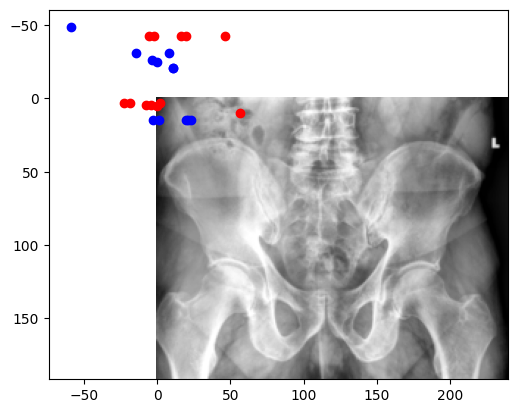

tensor([  5.6810,   6.1193,  37.3198,  50.7064,  40.8907,  77.6960,  34.6768,
        128.0840, 108.7329, 129.2067,   6.9156,   5.5715,  37.0163,  53.9146,
         38.6611,  77.0045,  34.6526, 128.0961, 108.2128, 127.3697],
       device='mps:0', grad_fn=<SelectBackward0>)
tensor([  6.6900,   5.4700,  42.2900,  61.8800,  50.1550,  91.9700,  43.8100,
        160.4750, 131.2200, 130.9050,   7.0650,   6.7050,  42.5850,  63.6850,
         50.0750,  98.6000,  44.7150, 163.3500, 130.1200, 128.5500],
       device='mps:0')
tensor([[-21.6041,   2.8839],
        [ -3.9890,   4.4690],
        [ 45.4243, -41.5867],
        [ -7.0826,   4.1906],
        [ -0.1372,   4.8156],
        [-18.1329,   3.1963],
        [ 54.8575,   9.7641],
        [ 16.1402, -41.5867],
        [ 19.4442, -41.5867],
        [ -1.7523, -41.5867],
        [ -5.2781, -41.5867],
        [  1.7595,   2.8839],
        [-14.1326, -29.8914],
        [ -2.9906, -25.4496],
        [ 20.3232,  14.2248],
        [  0.1902, -24.1816

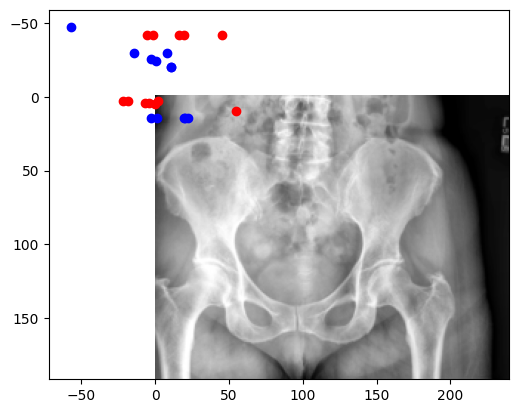

tensor([  5.6168,   5.9939,  36.4111,  49.5727,  39.7181,  75.6001,  34.0380,
        124.5850, 105.7235, 129.3344,   6.7161,   5.3830,  36.1295,  52.4247,
         37.8080,  74.9976,  32.9419, 124.5682, 105.1750, 127.2123],
       device='mps:0', grad_fn=<SelectBackward0>)
tensor([  6.1200,   6.9700,  37.4000,  51.5000,  43.6900,  73.1000,  35.4200,
        129.3000, 107.0800, 127.9200,   6.6300,   6.1200,  36.7200,  51.0600,
         43.6900,  81.0900,  35.1400, 132.8300, 109.6300, 132.5400],
       device='mps:0')
tensor([[-22.0780,   2.9435],
        [ -4.0306,   4.6051],
        [ 46.2183, -42.2764],
        [ -7.3543,   4.2991],
        [ -0.1463,   4.9628],
        [-18.5681,   3.2667],
        [ 55.6829,  10.1029],
        [ 16.3409, -42.2764],
        [ 19.6359, -42.2764],
        [ -1.8165, -42.2764],
        [ -5.4621, -42.2764],
        [  1.8356,   2.9435],
        [-14.2104, -30.3584],
        [ -3.0505, -25.9492],
        [ 20.6662,  14.5773],
        [  0.1809, -24.6724

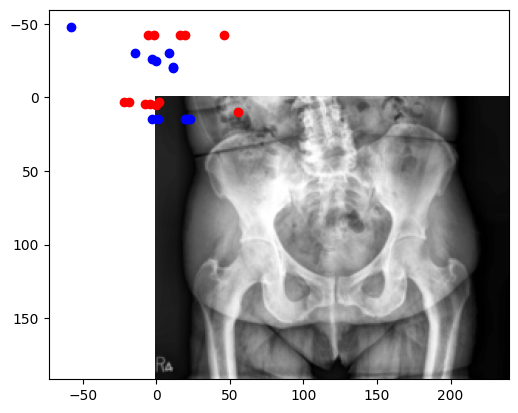

tensor([  5.6016,   6.1976,  37.0651,  50.2723,  40.6530,  76.8738,  35.6344,
        126.7607, 107.6165, 129.2043,   7.0098,   5.3847,  36.3844,  52.6112,
         38.4628,  76.3908,  33.2185, 126.4200, 106.5080, 126.8095],
       device='mps:0', grad_fn=<SelectBackward0>)
tensor([ 10.4800,   8.1100,  35.8200,  47.6900,  51.3600,  73.6700,  31.4100,
        117.2200, 105.2600, 123.1000,  12.1700,   7.1000,  35.1400,  48.2600,
         53.0500,  70.6200,  34.6700, 120.7200, 111.1500, 127.2000],
       device='mps:0')


In [277]:
model.eval()
for images, files in test_loader:
    images = images.to(device)
    
    yvals = []
    for file in files:
        yvals.append(df.loc[df['ID'] == file].drop(columns = 'ID').values.astype(np.float32))
    yvals = torch.from_numpy(np.stack(yvals)).squeeze(1).to(device)

    ypred, ypoints = all_points_to_measurements(model(images), pix_to_mm, scale_factor)

    loss = lossfn(ypred, yvals)
    total_loss += loss.item()

    total_percent_err += torch.sum(torch.abs(yvals - ypred) / yvals, dim = 0)

    cur_points = ypoints[0].detach().cpu()
    print(cur_points)

    plt.imshow(images[0].squeeze().cpu(), cmap = 'gray')
    plt.scatter(cur_points[:12, 0], cur_points[:12, 1], c = 'r')
    plt.scatter(cur_points[12:, 0], cur_points[12:, 1], c = 'b')
    # plt.axis('off')
    plt.show()

    print(ypred[0])
    print(yvals[0])